In [ ]:
# ============================================================
# BLOQUE 00 — MONTAR DRIVE E IMPORTS
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json
import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

print("Drive montado.")
print("Librerías cargadas.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montado.
Librerías cargadas.


In [ ]:
# ============================================================
# BLOQUE 01 — CONFIGURACIÓN MAESTRA INTEGRADA
# ============================================================

MASTER_CONFIG = {
    "config_name": "normalization_config_extracted_from_curve_centered_patches",

    "source_experiment_root": "/content/drive/MyDrive/TDA_PIPELINE/GRAY_TO_EXTRACTOR_CURVE_robust_mad",

    "source_curves_root": "/content/drive/MyDrive/TDA_PIPELINE/GRAY_TO_EXTRACTOR_CURVE_robust_mad/curvas_mascara_multicolor",

    "source_all_curves_csv": "/content/drive/MyDrive/TDA_PIPELINE/GRAY_TO_EXTRACTOR_CURVE_robust_mad/curvas_mascara_multicolor/all_curves.csv",

    "normalization": {
        "mode": "robust_mad",
        "p_low": 1.0,
        "p_high": 99.0,
        "mask_source": "processed_mask"
    },

    "resolution": {
        "standardize_long_side": True,
        "target_long_side": 1024,
        "keep_aspect_ratio": True,
        "pad_to_square": False
    },

    "patient_json_structure": {
        "patient_key_column": "patient_key",
        "patient_folder_root": "/content/drive/MyDrive/TDA_PIPELINE/GRAY_TO_EXTRACTOR_CURVE_robust_mad/curvas_mascara_multicolor",
        "normalization_json_relative_path": "{patient_key}/curve_centered_patches/normalization_info.json"
    },

    "dataset_summary": {
        "num_rows_all_curves": 250,
        "num_unique_patient_keys_all_curves": 250,
        "num_patient_json_expected": 250,
        "num_patient_json_found": 249,
        "num_patient_json_loaded_ok": 249,
        "num_patient_json_missing": 1
    },

    "expected_metadata_fields": [
        "patient_id",
        "normalization_mode",
        "normalization_p_low",
        "normalization_p_high",
        "normalization_mask_source",
        "original_shape",
        "resized_shape",
        "final_image_shape",
        "standardize_long_side",
        "target_long_side",
        "scale_x",
        "scale_y",
        "processed_mask_path",
        "image_before_norm_stats",
        "image_after_norm_stats"
    ]
}

print("MASTER_CONFIG cargado en memoria.")
print(json.dumps(MASTER_CONFIG, indent=4))

MASTER_CONFIG cargado en memoria.
{
    "config_name": "normalization_config_extracted_from_curve_centered_patches",
    "source_experiment_root": "/content/drive/MyDrive/TDA_PIPELINE/GRAY_TO_EXTRACTOR_CURVE_robust_mad",
    "source_curves_root": "/content/drive/MyDrive/TDA_PIPELINE/GRAY_TO_EXTRACTOR_CURVE_robust_mad/curvas_mascara_multicolor",
    "source_all_curves_csv": "/content/drive/MyDrive/TDA_PIPELINE/GRAY_TO_EXTRACTOR_CURVE_robust_mad/curvas_mascara_multicolor/all_curves.csv",
    "normalization": {
        "mode": "robust_mad",
        "p_low": 1.0,
        "p_high": 99.0,
        "mask_source": "processed_mask"
    },
    "resolution": {
        "standardize_long_side": true,
        "target_long_side": 1024,
        "keep_aspect_ratio": true,
        "pad_to_square": false
    },
    "patient_json_structure": {
        "patient_key_column": "patient_key",
        "patient_folder_root": "/content/drive/MyDrive/TDA_PIPELINE/GRAY_TO_EXTRACTOR_CURVE_robust_mad/curvas_mascara_mu

In [ ]:
# ============================================================
# BLOQUE 02 — PATHS DE ENTRADA Y SALIDA
# ============================================================

# Puede ser una carpeta completa o una sola imagen
INPUT_PATH = Path(
    "/content/drive/MyDrive/MaIA_Scoliosis_Dataset/LabelMultiClass_Gray_JPG"
)

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/TDA_PIPELINE/NORMALIZED_WITH_MASTER_CONFIG_INLINE"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert INPUT_PATH.exists(), f"No existe INPUT_PATH: {INPUT_PATH}"

print("INPUT_PATH:")
print(INPUT_PATH)

print("\nOUTPUT_DIR:")
print(OUTPUT_DIR)

INPUT_PATH:
/content/drive/MyDrive/MaIA_Scoliosis_Dataset/LabelMultiClass_Gray_JPG

OUTPUT_DIR:
/content/drive/MyDrive/TDA_PIPELINE/NORMALIZED_WITH_MASTER_CONFIG_INLINE


In [ ]:
# ============================================================
# BLOQUE 03 — CLASE MASTER CONFIG INLINE
# ============================================================

class InlineNormalizationMasterConfig:
    def __init__(self, config_dict):
        assert isinstance(config_dict, dict), "config_dict debe ser un diccionario."

        self.config = config_dict

    def get_normalization_mode(self):
        return self.config["normalization"]["mode"]

    def get_p_low(self):
        return float(self.config["normalization"].get("p_low", 1.0))

    def get_p_high(self):
        return float(self.config["normalization"].get("p_high", 99.0))

    def get_mask_source(self):
        return self.config["normalization"].get("mask_source", "processed_mask")

    def get_target_long_side(self):
        return int(self.config["resolution"].get("target_long_side", 1024))

    def standardize_long_side(self):
        return bool(self.config["resolution"].get("standardize_long_side", True))

    def keep_aspect_ratio(self):
        return bool(self.config["resolution"].get("keep_aspect_ratio", True))

    def pad_to_square(self):
        return bool(self.config["resolution"].get("pad_to_square", False))

    def get_patient_json_path(self, patient_key):
        patient_root = Path(
            self.config["patient_json_structure"]["patient_folder_root"]
        )

        relative_template = self.config["patient_json_structure"][
            "normalization_json_relative_path"
        ]

        relative_path = relative_template.format(patient_key=patient_key)

        return patient_root / relative_path

    def summary(self):
        print(json.dumps(self.config, indent=4))


master_cfg = InlineNormalizationMasterConfig(MASTER_CONFIG)

print("Modo de normalización:", master_cfg.get_normalization_mode())
print("Target long side:", master_cfg.get_target_long_side())
print("Pad to square:", master_cfg.pad_to_square())

Modo de normalización: robust_mad
Target long side: 1024
Pad to square: False


In [ ]:
# ============================================================
# BLOQUE 04 — CLASE IMAGE STATS
# ============================================================

class ImageStats:
    @staticmethod
    def compute(image):
        image = image.astype(np.float32)

        return {
            "min": float(np.min(image)),
            "max": float(np.max(image)),
            "mean": float(np.mean(image)),
            "std": float(np.std(image)),
            "median": float(np.median(image)),
            "p1": float(np.percentile(image, 1)),
            "p5": float(np.percentile(image, 5)),
            "p95": float(np.percentile(image, 95)),
            "p99": float(np.percentile(image, 99)),
        }

In [ ]:
# ============================================================
# BLOQUE 05 — CLASE RESOLUTION NORMALIZER
# ============================================================

class ResolutionNormalizer:
    def __init__(self, master_config):
        self.master_config = master_config

        self.target_long_side = master_config.get_target_long_side()
        self.do_standardize = master_config.standardize_long_side()
        self.do_pad_to_square = master_config.pad_to_square()

    def normalize(self, image):
        original_h, original_w = image.shape[:2]

        if self.do_standardize:
            resized, scale_x, scale_y = self._resize_long_side(image)
        else:
            resized = image.copy()
            scale_x = 1.0
            scale_y = 1.0

        if self.do_pad_to_square:
            final = self._pad_to_square(resized)
        else:
            final = resized

        resized_h, resized_w = resized.shape[:2]
        final_h, final_w = final.shape[:2]

        metadata = {
            "original_shape": [int(original_h), int(original_w)],
            "resized_shape": [int(resized_h), int(resized_w)],
            "final_image_shape": [int(final_h), int(final_w)],
            "standardize_long_side": bool(self.do_standardize),
            "target_long_side": int(self.target_long_side),
            "scale_x": float(scale_x),
            "scale_y": float(scale_y),
        }

        return final, metadata

    def _resize_long_side(self, image):
        h, w = image.shape[:2]

        scale = self.target_long_side / max(h, w)

        new_h = int(round(h * scale))
        new_w = int(round(w * scale))

        interpolation = cv2.INTER_AREA if scale < 1.0 else cv2.INTER_CUBIC

        resized = cv2.resize(
            image,
            (new_w, new_h),
            interpolation=interpolation
        )

        return resized, scale, scale

    def _pad_to_square(self, image):
        h, w = image.shape[:2]
        size = max(h, w)

        canvas = np.zeros((size, size), dtype=image.dtype)

        y0 = (size - h) // 2
        x0 = (size - w) // 2

        canvas[y0:y0+h, x0:x0+w] = image

        return canvas

In [ ]:
# ============================================================
# BLOQUE 06 — CLASE INTENSITY NORMALIZER
# ============================================================

class IntensityNormalizer:
    def __init__(self, master_config):
        self.master_config = master_config

        self.mode = master_config.get_normalization_mode()
        self.p_low = master_config.get_p_low()
        self.p_high = master_config.get_p_high()

    def normalize(self, image):
        image = image.astype(np.float32)

        before_stats = ImageStats.compute(image)

        if self.mode == "robust_mad":
            normalized = self._robust_mad(image)

        elif self.mode == "percentile":
            normalized = self._percentile(image)

        elif self.mode == "minmax":
            normalized = self._minmax(image)

        elif self.mode == "zscore":
            normalized = self._zscore(image)

        elif self.mode == "none":
            normalized = image.copy()

        else:
            raise ValueError(f"Modo de normalización no soportado: {self.mode}")

        normalized_uint8 = self._to_uint8(normalized)

        after_stats = ImageStats.compute(normalized_uint8)

        metadata = {
            "normalization_mode": self.mode,
            "normalization_p_low": float(self.p_low),
            "normalization_p_high": float(self.p_high),
            "normalization_mask_source": self.master_config.get_mask_source(),
            "image_before_norm_stats": before_stats,
            "image_after_norm_stats": after_stats,
        }

        return normalized_uint8, metadata

    def _percentile(self, image):
        low = np.percentile(image, self.p_low)
        high = np.percentile(image, self.p_high)

        if high - low < 1e-8:
            return np.zeros_like(image)

        clipped = np.clip(image, low, high)

        normalized = (clipped - low) / (high - low)
        normalized = normalized * 255.0

        return normalized

    def _robust_mad(self, image):
        low = np.percentile(image, self.p_low)
        high = np.percentile(image, self.p_high)

        image_clip = np.clip(image, low, high)

        median = np.median(image_clip)
        mad = np.median(np.abs(image_clip - median))

        if mad < 1e-8:
            return self._percentile(image)

        robust_z = (image_clip - median) / (1.4826 * mad + 1e-8)

        robust_z = np.clip(robust_z, -4.0, 4.0)

        normalized = (robust_z + 4.0) / 8.0
        normalized = normalized * 255.0

        return normalized

    def _minmax(self, image):
        img_min = np.min(image)
        img_max = np.max(image)

        if img_max - img_min < 1e-8:
            return np.zeros_like(image)

        normalized = (image - img_min) / (img_max - img_min)
        normalized = normalized * 255.0

        return normalized

    def _zscore(self, image):
        mean = np.mean(image)
        std = np.std(image)

        if std < 1e-8:
            return np.zeros_like(image)

        z = (image - mean) / std
        z = np.clip(z, -3.0, 3.0)

        normalized = (z + 3.0) / 6.0
        normalized = normalized * 255.0

        return normalized

    def _to_uint8(self, image):
        image = np.nan_to_num(
            image,
            nan=0.0,
            posinf=255.0,
            neginf=0.0
        )

        image = np.clip(image, 0, 255)

        return image.astype(np.uint8)

In [ ]:
# ============================================================
# BLOQUE 07 — CLASE PIPELINE FINAL DE NORMALIZACIÓN
# ============================================================

class ImageNormalizationPipeline:
    def __init__(self, master_config_dict, output_dir):
        self.master_config = InlineNormalizationMasterConfig(master_config_dict)

        self.output_dir = Path(output_dir)

        self.normalized_images_dir = self.output_dir / "normalized_images"
        self.normalization_json_dir = self.output_dir / "normalization_json"
        self.config_snapshot_dir = self.output_dir / "config_snapshot"

        self.normalized_images_dir.mkdir(parents=True, exist_ok=True)
        self.normalization_json_dir.mkdir(parents=True, exist_ok=True)
        self.config_snapshot_dir.mkdir(parents=True, exist_ok=True)

        self.resolution_normalizer = ResolutionNormalizer(self.master_config)
        self.intensity_normalizer = IntensityNormalizer(self.master_config)

        self._save_config_snapshot()

    def _save_config_snapshot(self):
        config_out = self.config_snapshot_dir / "master_config_used.json"

        with open(config_out, "w", encoding="utf-8") as f:
            json.dump(self.master_config.config, f, indent=4, ensure_ascii=False)

        self.config_snapshot_path = config_out

    def read_image(self, image_path):
        image_path = Path(image_path)

        image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise ValueError(f"No se pudo leer la imagen: {image_path}")

        return image

    def infer_patient_key(self, image_path):
        image_path = Path(image_path)

        name = image_path.stem

        return name

    def find_images(self, input_path):
        input_path = Path(input_path)

        valid_exts = [
            ".jpg", ".jpeg", ".png",
            ".bmp", ".tif", ".tiff"
        ]

        if input_path.is_file():
            return [input_path]

        image_paths = []

        for ext in valid_exts:
            image_paths.extend(input_path.rglob(f"*{ext}"))
            image_paths.extend(input_path.rglob(f"*{ext.upper()}"))

        image_paths = sorted(list(set(image_paths)))

        return image_paths

    def normalize_one(self, image_path, patient_key=None):
        image_path = Path(image_path)

        if patient_key is None:
            patient_key = self.infer_patient_key(image_path)

        image_original = self.read_image(image_path)

        image_resized, resolution_meta = self.resolution_normalizer.normalize(
            image_original
        )

        image_normalized, intensity_meta = self.intensity_normalizer.normalize(
            image_resized
        )

        output_image_path = self.normalized_images_dir / f"{patient_key}.png"

        output_json_path = self.normalization_json_dir / f"{patient_key}_normalization_info.json"

        ok = cv2.imwrite(str(output_image_path), image_normalized)

        if not ok:
            raise RuntimeError(f"No se pudo guardar imagen: {output_image_path}")

        expected_patient_json = self.master_config.get_patient_json_path(patient_key)

        metadata = {
            "patient_id": patient_key,
            "patient_key": patient_key,
            "input_image_path": str(image_path),
            "output_image_path": str(output_image_path),
            "normalization_json_path": str(output_json_path),
            "expected_original_normalization_json_path": str(expected_patient_json),
            "expected_original_normalization_json_exists": bool(expected_patient_json.exists()),
            "master_config_snapshot_path": str(self.config_snapshot_path),
        }

        metadata.update(intensity_meta)
        metadata.update(resolution_meta)

        with open(output_json_path, "w", encoding="utf-8") as f:
            json.dump(metadata, f, indent=4, ensure_ascii=False)

        summary_row = {
            "patient_key": patient_key,
            "input_image_path": str(image_path),
            "output_image_path": str(output_image_path),
            "normalization_json_path": str(output_json_path),
            "status": "ok",
            "error": "",
            "normalization_mode": intensity_meta["normalization_mode"],
            "normalization_p_low": intensity_meta["normalization_p_low"],
            "normalization_p_high": intensity_meta["normalization_p_high"],
            "normalization_mask_source": intensity_meta["normalization_mask_source"],
            "original_shape": resolution_meta["original_shape"],
            "resized_shape": resolution_meta["resized_shape"],
            "final_image_shape": resolution_meta["final_image_shape"],
            "scale_x": resolution_meta["scale_x"],
            "scale_y": resolution_meta["scale_y"],
            "target_long_side": resolution_meta["target_long_side"],
            "standardize_long_side": resolution_meta["standardize_long_side"],
            "expected_original_normalization_json_exists": bool(expected_patient_json.exists()),
        }

        return summary_row

    def run(self, input_path, max_images=None):
        image_paths = self.find_images(input_path)

        if max_images is not None:
            image_paths = image_paths[:max_images]

        print("Imágenes encontradas:", len(image_paths))

        rows = []

        for image_path in tqdm(image_paths, desc="Normalizando imágenes"):
            try:
                row = self.normalize_one(image_path)
            except Exception as e:
                row = {
                    "patient_key": Path(image_path).stem,
                    "input_image_path": str(image_path),
                    "output_image_path": "",
                    "normalization_json_path": "",
                    "status": "error",
                    "error": str(e),
                }

            rows.append(row)

        df_summary = pd.DataFrame(rows)

        summary_csv_path = self.output_dir / "normalization_run_summary.csv"
        summary_jsonl_path = self.output_dir / "normalization_run_summary.jsonl"

        df_summary_csv = df_summary.copy()

        for col in df_summary_csv.columns:
            if df_summary_csv[col].apply(lambda x: isinstance(x, (dict, list))).any():
                df_summary_csv[col] = df_summary_csv[col].apply(
                    lambda x: json.dumps(x, ensure_ascii=False)
                    if isinstance(x, (dict, list))
                    else x
                )

        df_summary_csv.to_csv(summary_csv_path, index=False)

        with open(summary_jsonl_path, "w", encoding="utf-8") as f:
            for record in df_summary.to_dict(orient="records"):
                f.write(json.dumps(record, ensure_ascii=False) + "\n")

        print("Resumen CSV guardado en:")
        print(summary_csv_path)

        print("\nResumen JSONL guardado en:")
        print(summary_jsonl_path)

        return df_summary

In [ ]:
# ============================================================
# BLOQUE 08 — CREAR PIPELINE
# ============================================================

pipeline = ImageNormalizationPipeline(
    master_config_dict=MASTER_CONFIG,
    output_dir=OUTPUT_DIR
)

print("Pipeline creado correctamente.")
print("Config usada guardada en:")
print(pipeline.config_snapshot_path)

Pipeline creado correctamente.
Config usada guardada en:
/content/drive/MyDrive/TDA_PIPELINE/NORMALIZED_WITH_MASTER_CONFIG_INLINE/config_snapshot/master_config_used.json


In [ ]:
# ============================================================
# BLOQUE 00 — JSON SIMPLE CON IMAGEN Y OUTPUT_DIR
# ============================================================

from pathlib import Path
import json

RUN_CONFIG = {
    "input_image_path": "/content/drive/MyDrive/MaIA_Scoliosis_Dataset/Scoliosis/S_100.jpg",
    "output_dir": "/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZED_SINGLE_IMAGE_TEST",
    "output_filename": "S_100_normalized.png"
}

RUN_CONFIG_PATH = Path("/content/drive/MyDrive/TDA_PIPELINE/run_normalization_single_image.json")

RUN_CONFIG_PATH.parent.mkdir(parents=True, exist_ok=True)

with open(RUN_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(RUN_CONFIG, f, indent=4, ensure_ascii=False)

print("RUN_CONFIG guardado en:")
print(RUN_CONFIG_PATH)

print(json.dumps(RUN_CONFIG, indent=4))

RUN_CONFIG guardado en:
/content/drive/MyDrive/TDA_PIPELINE/run_normalization_single_image.json
{
    "input_image_path": "/content/drive/MyDrive/MaIA_Scoliosis_Dataset/Scoliosis/S_100.jpg",
    "output_dir": "/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZED_SINGLE_IMAGE_TEST",
    "output_filename": "S_100_normalized.png"
}


In [ ]:
# ============================================================
# BLOQUE 01 — CARGAR JSON SIMPLE
# ============================================================

from pathlib import Path
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

with open(RUN_CONFIG_PATH, "r", encoding="utf-8") as f:
    run_cfg = json.load(f)

INPUT_IMAGE_PATH = Path(run_cfg["input_image_path"])
OUTPUT_DIR = Path(run_cfg["output_dir"])
OUTPUT_FILENAME = run_cfg.get("output_filename", INPUT_IMAGE_PATH.stem + "_normalized.png")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert INPUT_IMAGE_PATH.exists(), f"No existe la imagen: {INPUT_IMAGE_PATH}"

OUTPUT_IMAGE_PATH = OUTPUT_DIR / OUTPUT_FILENAME

print("Imagen de entrada:")
print(INPUT_IMAGE_PATH)

print("\nDirectorio de salida:")
print(OUTPUT_DIR)

print("\nImagen normalizada se guardará en:")
print(OUTPUT_IMAGE_PATH)

Imagen de entrada:
/content/drive/MyDrive/MaIA_Scoliosis_Dataset/Scoliosis/S_100.jpg

Directorio de salida:
/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZED_SINGLE_IMAGE_TEST

Imagen normalizada se guardará en:
/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZED_SINGLE_IMAGE_TEST/S_100_normalized.png


In [ ]:
# ============================================================
# BLOQUE 02 — NORMALIZAR UNA IMAGEN DESDE JSON SIMPLE
# ============================================================

def compute_image_stats(image):
    image = image.astype(np.float32)

    return {
        "min": float(np.min(image)),
        "max": float(np.max(image)),
        "mean": float(np.mean(image)),
        "std": float(np.std(image)),
        "median": float(np.median(image)),
        "p1": float(np.percentile(image, 1)),
        "p5": float(np.percentile(image, 5)),
        "p95": float(np.percentile(image, 95)),
        "p99": float(np.percentile(image, 99)),
    }


def resize_long_side(image, target_long_side=1024):
    h, w = image.shape[:2]

    scale = target_long_side / max(h, w)

    new_h = int(round(h * scale))
    new_w = int(round(w * scale))

    interpolation = cv2.INTER_AREA if scale < 1.0 else cv2.INTER_CUBIC

    resized = cv2.resize(
        image,
        (new_w, new_h),
        interpolation=interpolation
    )

    metadata = {
        "original_shape": [int(h), int(w)],
        "resized_shape": [int(new_h), int(new_w)],
        "final_image_shape": [int(new_h), int(new_w)],
        "standardize_long_side": True,
        "target_long_side": int(target_long_side),
        "scale_x": float(scale),
        "scale_y": float(scale),
    }

    return resized, metadata


def robust_mad_normalize(image, p_low=1.0, p_high=99.0):
    image = image.astype(np.float32)

    before_stats = compute_image_stats(image)

    low = np.percentile(image, p_low)
    high = np.percentile(image, p_high)

    image_clip = np.clip(image, low, high)

    median = np.median(image_clip)
    mad = np.median(np.abs(image_clip - median))

    if mad < 1e-8:
        normalized = (image_clip - low) / max(high - low, 1e-8)
        normalized = normalized * 255.0
    else:
        robust_z = (image_clip - median) / (1.4826 * mad + 1e-8)
        robust_z = np.clip(robust_z, -4.0, 4.0)

        normalized = (robust_z + 4.0) / 8.0
        normalized = normalized * 255.0

    normalized = np.nan_to_num(normalized, nan=0.0, posinf=255.0, neginf=0.0)
    normalized = np.clip(normalized, 0, 255).astype(np.uint8)

    after_stats = compute_image_stats(normalized)

    metadata = {
        "normalization_mode": "robust_mad",
        "normalization_p_low": float(p_low),
        "normalization_p_high": float(p_high),
        "normalization_mask_source": "processed_mask",
        "image_before_norm_stats": before_stats,
        "image_after_norm_stats": after_stats,
    }

    return normalized, metadata


# Leer imagen
image_original = cv2.imread(str(INPUT_IMAGE_PATH), cv2.IMREAD_GRAYSCALE)

assert image_original is not None, f"No se pudo leer la imagen: {INPUT_IMAGE_PATH}"

# Normalizar resolución
image_resized, resolution_meta = resize_long_side(
    image_original,
    target_long_side=MASTER_CONFIG["resolution"]["target_long_side"]
)

# Normalizar intensidad
image_normalized, intensity_meta = robust_mad_normalize(
    image_resized,
    p_low=MASTER_CONFIG["normalization"]["p_low"],
    p_high=MASTER_CONFIG["normalization"]["p_high"]
)

# Guardar imagen
ok = cv2.imwrite(str(OUTPUT_IMAGE_PATH), image_normalized)

assert ok, f"No se pudo guardar la imagen normalizada: {OUTPUT_IMAGE_PATH}"

print("Imagen normalizada guardada en:")
print(OUTPUT_IMAGE_PATH)

Imagen normalizada guardada en:
/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZED_SINGLE_IMAGE_TEST/S_100_normalized.png


In [ ]:
# ============================================================
# BLOQUE FIX-NORM-01 — ROBUST MAD COMPATIBLE CON HISTÓRICO
# ============================================================

def compute_image_stats(image):
    image = image.astype(np.float32)

    return {
        "min": float(np.min(image)),
        "max": float(np.max(image)),
        "mean": float(np.mean(image)),
        "std": float(np.std(image)),
        "median": float(np.median(image)),
        "p1": float(np.percentile(image, 1)),
        "p5": float(np.percentile(image, 5)),
        "p95": float(np.percentile(image, 95)),
        "p99": float(np.percentile(image, 99)),
    }


def robust_mad_normalize_historical_like(
    image,
    p_low=1.0,
    p_high=99.0,
    z_clip=4.0,
    eps=1e-8
):
    """
    Normalización robust_mad tipo histórico:

    1) Clip por percentiles p1-p99
    2) Robust z-score usando mediana y MAD
    3) Clip robust z en [-4, 4]
    4) Stretch final usando min/max del robust_z recortado
    5) Convertir a uint8 0-255

    Esto fuerza que el resultado sí pueda ocupar rango completo 0-255.
    """

    image = image.astype(np.float32)

    before_stats = compute_image_stats(image)

    # 1) Percentile clipping
    low = np.percentile(image, p_low)
    high = np.percentile(image, p_high)

    image_clip = np.clip(image, low, high)

    # 2) Mediana y MAD
    median = np.median(image_clip)
    mad = np.median(np.abs(image_clip - median))

    if mad < eps:
        # fallback percentile
        normalized = (image_clip - low) / max(high - low, eps)
        normalized = normalized * 255.0
    else:
        # 3) Robust z
        robust_z = (image_clip - median) / (1.4826 * mad + eps)

        robust_z = np.clip(
            robust_z,
            -float(z_clip),
            float(z_clip)
        )

        # 4) Stretch final real a 0-255
        rz_min = np.min(robust_z)
        rz_max = np.max(robust_z)

        if rz_max - rz_min < eps:
            normalized = np.zeros_like(robust_z)
        else:
            normalized = (robust_z - rz_min) / (rz_max - rz_min)
            normalized = normalized * 255.0

    normalized = np.nan_to_num(
        normalized,
        nan=0.0,
        posinf=255.0,
        neginf=0.0
    )

    normalized = np.clip(normalized, 0, 255).astype(np.uint8)

    after_stats = compute_image_stats(normalized)

    metadata = {
        "normalization_mode": "robust_mad",
        "normalization_p_low": float(p_low),
        "normalization_p_high": float(p_high),
        "normalization_mask_source": "processed_mask",
        "robust_mad_z_clip": float(z_clip),
        "robust_mad_with_final_stretch": True,
        "image_before_norm_stats": before_stats,
        "image_after_norm_stats": after_stats,
    }

    return normalized, metadata

In [ ]:
# ============================================================
# BLOQUE FIX-NORM-02 — REGENERAR S_100 NORMALIZADO
# ============================================================

from pathlib import Path
import json
import cv2
import numpy as np

INPUT_IMAGE_PATH = Path(
    "/content/drive/MyDrive/MaIA_Scoliosis_Dataset/Scoliosis/S_100.jpg"
)

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZED_SINGLE_IMAGE_TEST"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_IMAGE_PATH = OUTPUT_DIR / "S_100_normalized_FIXED.png"
OUTPUT_JSON_PATH = OUTPUT_DIR / "S_100_normalization_info_FIXED.json"

assert INPUT_IMAGE_PATH.exists(), f"No existe imagen: {INPUT_IMAGE_PATH}"

image_original = cv2.imread(str(INPUT_IMAGE_PATH), cv2.IMREAD_GRAYSCALE)

assert image_original is not None, f"No se pudo leer: {INPUT_IMAGE_PATH}"

# 1) Resize long side a 1024
image_resized, resolution_meta = resize_long_side(
    image_original,
    target_long_side=1024
)

# 2) Robust MAD corregido
image_normalized, intensity_meta = robust_mad_normalize_historical_like(
    image_resized,
    p_low=1.0,
    p_high=99.0,
    z_clip=4.0
)

# 3) Guardar imagen
ok = cv2.imwrite(str(OUTPUT_IMAGE_PATH), image_normalized)

assert ok, f"No se pudo guardar: {OUTPUT_IMAGE_PATH}"

# 4) Guardar JSON
normalization_info = {
    "patient_id": "S_100",
    "patient_key": "S_100",
    "input_image_path": str(INPUT_IMAGE_PATH),
    "output_image_path": str(OUTPUT_IMAGE_PATH),
    "output_dir": str(OUTPUT_DIR),
}

normalization_info.update(intensity_meta)
normalization_info.update(resolution_meta)

with open(OUTPUT_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(normalization_info, f, indent=4, ensure_ascii=False)

print("Imagen corregida guardada en:")
print(OUTPUT_IMAGE_PATH)

print("\nJSON corregido guardado en:")
print(OUTPUT_JSON_PATH)

print("\nStats after:")
print(json.dumps(intensity_meta["image_after_norm_stats"], indent=4))

Imagen corregida guardada en:
/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZED_SINGLE_IMAGE_TEST/S_100_normalized_FIXED.png

JSON corregido guardado en:
/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZED_SINGLE_IMAGE_TEST/S_100_normalization_info_FIXED.json

Stats after:
{
    "min": 0.0,
    "max": 255.0,
    "mean": 103.24114990234375,
    "std": 57.48281478881836,
    "median": 99.0,
    "p1": 0.0,
    "p5": 16.0,
    "p95": 206.0,
    "p99": 255.0
}


In [ ]:
# ============================================================
# BLOQUE FIX-NORM-03 — COMPARAR NORMALIZACIÓN VIEJA VS CORREGIDA
# ============================================================

OLD_IMAGE_PATH = Path(
    "/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZED_SINGLE_IMAGE_TEST/S_100_normalized.png"
)

NEW_IMAGE_PATH = Path(
    "/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZED_SINGLE_IMAGE_TEST/S_100_normalized_FIXED.png"
)

img_old = cv2.imread(str(OLD_IMAGE_PATH), cv2.IMREAD_GRAYSCALE)
img_new = cv2.imread(str(NEW_IMAGE_PATH), cv2.IMREAD_GRAYSCALE)

assert img_old is not None, f"No se pudo leer OLD: {OLD_IMAGE_PATH}"
assert img_new is not None, f"No se pudo leer NEW: {NEW_IMAGE_PATH}"

print("OLD stats:")
print(json.dumps(compute_image_stats(img_old), indent=4))

print("\nNEW stats:")
print(json.dumps(compute_image_stats(img_new), indent=4))

OLD stats:
{
    "min": 75.0,
    "max": 208.0,
    "mean": 129.03086853027344,
    "std": 29.969308853149414,
    "median": 127.0,
    "p1": 75.0,
    "p5": 83.0,
    "p95": 182.0,
    "p99": 208.0
}

NEW stats:
{
    "min": 0.0,
    "max": 255.0,
    "mean": 103.24114990234375,
    "std": 57.48281478881836,
    "median": 99.0,
    "p1": 0.0,
    "p5": 16.0,
    "p95": 206.0,
    "p99": 255.0
}


In [ ]:
# ============================================================
# BLOQUE DIAG-01 — VARIANTES DE NORMALIZACIÓN ROBUST MAD
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

INPUT_IMAGE_PATH = Path(
    "/content/drive/MyDrive/MaIA_Scoliosis_Dataset/Scoliosis/S_100.jpg"
)

assert INPUT_IMAGE_PATH.exists(), f"No existe: {INPUT_IMAGE_PATH}"

img_original = cv2.imread(str(INPUT_IMAGE_PATH), cv2.IMREAD_GRAYSCALE)
assert img_original is not None

img_resized, resolution_meta = resize_long_side(img_original, target_long_side=1024)

def stats(img):
    img = img.astype(np.float32)
    return {
        "min": float(np.min(img)),
        "max": float(np.max(img)),
        "mean": float(np.mean(img)),
        "std": float(np.std(img)),
        "median": float(np.median(img)),
        "p1": float(np.percentile(img, 1)),
        "p5": float(np.percentile(img, 5)),
        "p95": float(np.percentile(img, 95)),
        "p99": float(np.percentile(img, 99)),
    }


def robust_mad_with_reference_pixels(image, ref_pixels, p_low=1, p_high=99, z_clip=4.0):
    image = image.astype(np.float32)
    ref_pixels = ref_pixels.astype(np.float32)

    low = np.percentile(ref_pixels, p_low)
    high = np.percentile(ref_pixels, p_high)

    image_clip = np.clip(image, low, high)
    ref_clip = np.clip(ref_pixels, low, high)

    median = np.median(ref_clip)
    mad = np.median(np.abs(ref_clip - median))

    if mad < 1e-8:
        normalized = (image_clip - low) / max(high - low, 1e-8)
        normalized = normalized * 255.0
    else:
        robust_z = (image_clip - median) / (1.4826 * mad + 1e-8)
        robust_z = np.clip(robust_z, -z_clip, z_clip)

        rz_min = np.min(robust_z)
        rz_max = np.max(robust_z)

        normalized = (robust_z - rz_min) / max(rz_max - rz_min, 1e-8)
        normalized = normalized * 255.0

    return np.clip(normalized, 0, 255).astype(np.uint8)


# Variante A: usar toda la imagen
ref_all = img_resized.reshape(-1)

img_norm_all = robust_mad_with_reference_pixels(
    img_resized,
    ref_all,
    p_low=1,
    p_high=99
)

# Variante B: usar solo pixeles positivos
ref_positive = img_resized[img_resized > 0]

img_norm_positive = robust_mad_with_reference_pixels(
    img_resized,
    ref_positive,
    p_low=1,
    p_high=99
)

print("Stats resized original:")
print(json.dumps(stats(img_resized), indent=4))

print("\nStats normalizada usando toda la imagen:")
print(json.dumps(stats(img_norm_all), indent=4))

print("\nStats normalizada usando pixeles > 0:")
print(json.dumps(stats(img_norm_positive), indent=4))

Stats resized original:
{
    "min": 0.0,
    "max": 255.0,
    "mean": 107.57259368896484,
    "std": 53.1930046081543,
    "median": 104.0,
    "p1": 12.0,
    "p5": 27.0,
    "p95": 202.0,
    "p99": 247.0
}

Stats normalizada usando toda la imagen:
{
    "min": 0.0,
    "max": 255.0,
    "mean": 103.24114990234375,
    "std": 57.48281478881836,
    "median": 99.0,
    "p1": 0.0,
    "p5": 16.0,
    "p95": 206.0,
    "p99": 255.0
}

Stats normalizada usando pixeles > 0:
{
    "min": 0.0,
    "max": 255.0,
    "mean": 102.59320831298828,
    "std": 57.70925521850586,
    "median": 99.0,
    "p1": 0.0,
    "p5": 15.0,
    "p95": 205.0,
    "p99": 255.0
}


In [ ]:
# ============================================================
# BLOQUE DIAG-03 — BUSCAR HISTÓRICO S_100
# ============================================================

HIST_ROOT = Path(
    "/content/drive/MyDrive/TDA_PIPELINE/GRAY_TO_EXTRACTOR_CURVE_robust_mad/curvas_mascara_multicolor"
)

PATIENT_KEY = "S_100"

candidate_paths = [
    HIST_ROOT / PATIENT_KEY / "processed_mask.png",
    HIST_ROOT / PATIENT_KEY / "curve_centered_patches" / "normalized_full_image.png",
    HIST_ROOT / PATIENT_KEY / "curve_centered_patches" / "processed_mask.png",
]

candidate_paths += sorted((HIST_ROOT / PATIENT_KEY).glob("**/*.png"))

print("Candidatos históricos:")
for i, p in enumerate(candidate_paths[:30]):
    print(i, p, "exists=", p.exists())

hist_img_path = None
for p in candidate_paths:
    if p.exists():
        hist_img_path = p
        break

print("\nSeleccionado histórico:")
print(hist_img_path)

Candidatos históricos:
0 /content/drive/MyDrive/TDA_PIPELINE/GRAY_TO_EXTRACTOR_CURVE_robust_mad/curvas_mascara_multicolor/S_100/processed_mask.png exists= False
1 /content/drive/MyDrive/TDA_PIPELINE/GRAY_TO_EXTRACTOR_CURVE_robust_mad/curvas_mascara_multicolor/S_100/curve_centered_patches/normalized_full_image.png exists= True
2 /content/drive/MyDrive/TDA_PIPELINE/GRAY_TO_EXTRACTOR_CURVE_robust_mad/curvas_mascara_multicolor/S_100/curve_centered_patches/processed_mask.png exists= False
3 /content/drive/MyDrive/TDA_PIPELINE/GRAY_TO_EXTRACTOR_CURVE_robust_mad/curvas_mascara_multicolor/S_100/curve_centered_patches/filtered_full_images/00__clahe__bilateral__scharr_var-False_mode-none_pk-128__128_st-32_vk-7.png exists= True
4 /content/drive/MyDrive/TDA_PIPELINE/GRAY_TO_EXTRACTOR_CURVE_robust_mad/curvas_mascara_multicolor/S_100/curve_centered_patches/filtered_full_images/01__clahe__bilateral__sobel_var-False_mode-none_pk-128__128_st-32_vk-7.png exists= True
5 /content/drive/MyDrive/TDA_PIPELIN

Histórico stats:
{
    "min": 0.0,
    "max": 255.0,
    "mean": 102.9273910522461,
    "std": 57.510799407958984,
    "median": 99.0,
    "p1": 0.0,
    "p5": 15.0,
    "p95": 204.0,
    "p99": 255.0
}

Comparación histórico vs all:
{
    "mae": 1.5254981517791748,
    "rmse": 2.4545931816101074,
    "max_abs_diff": 37.0,
    "p95_abs_diff": 5.0,
    "p99_abs_diff": 9.0
}

Comparación histórico vs positive:
{
    "mae": 1.419984221458435,
    "rmse": 2.4728288650512695,
    "max_abs_diff": 37.0,
    "p95_abs_diff": 6.0,
    "p99_abs_diff": 9.0
}


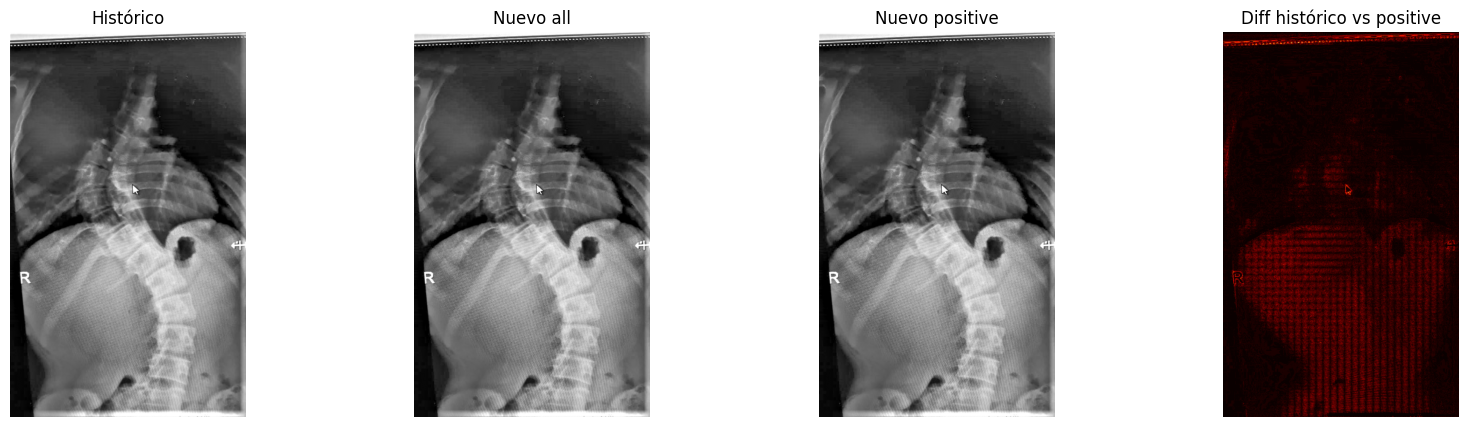

In [ ]:
# ============================================================
# BLOQUE DIAG-04 — COMPARAR VARIANTES CONTRA HISTÓRICO
# ============================================================

if hist_img_path is not None:
    img_hist = cv2.imread(str(hist_img_path), cv2.IMREAD_GRAYSCALE)
    assert img_hist is not None

    if img_hist.shape != img_norm_all.shape:
        img_hist_cmp = cv2.resize(
            img_hist,
            (img_norm_all.shape[1], img_norm_all.shape[0]),
            interpolation=cv2.INTER_AREA
        )
    else:
        img_hist_cmp = img_hist.copy()

    def compare(a, b):
        d = a.astype(np.float32) - b.astype(np.float32)
        ad = np.abs(d)
        return {
            "mae": float(np.mean(ad)),
            "rmse": float(np.sqrt(np.mean(d ** 2))),
            "max_abs_diff": float(np.max(ad)),
            "p95_abs_diff": float(np.percentile(ad, 95)),
            "p99_abs_diff": float(np.percentile(ad, 99)),
        }

    print("Histórico stats:")
    print(json.dumps(stats(img_hist_cmp), indent=4))

    print("\nComparación histórico vs all:")
    print(json.dumps(compare(img_hist_cmp, img_norm_all), indent=4))

    print("\nComparación histórico vs positive:")
    print(json.dumps(compare(img_hist_cmp, img_norm_positive), indent=4))

    plt.figure(figsize=(20, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(img_hist_cmp, cmap="gray")
    plt.title("Histórico")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(img_norm_all, cmap="gray")
    plt.title("Nuevo all")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(img_norm_positive, cmap="gray")
    plt.title("Nuevo positive")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(np.abs(img_hist_cmp.astype(np.float32) - img_norm_positive.astype(np.float32)), cmap="hot")
    plt.title("Diff histórico vs positive")
    plt.axis("off")

    plt.show()
else:
    print("No encontré histórico para S_100.")

In [ ]:
# ============================================================
# BLOQUE 00 — ROOTS PARA PERFILES HISTÓRICOS
# ============================================================

from pathlib import Path
import json
import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

HIST_ROOT = Path(
    "/content/drive/MyDrive/TDA_PIPELINE/GRAY_TO_EXTRACTOR_CURVE_robust_mad/curvas_mascara_multicolor"
)

PROFILE_OUT_DIR = Path(
    "/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZATION_PROFILES"
)

PROFILE_JSON_DIR = PROFILE_OUT_DIR / "patient_json_profiles"
PROFILE_JSON_DIR.mkdir(parents=True, exist_ok=True)

assert HIST_ROOT.exists(), f"No existe HIST_ROOT: {HIST_ROOT}"

print("HIST_ROOT:", HIST_ROOT)
print("PROFILE_JSON_DIR:", PROFILE_JSON_DIR)

HIST_ROOT: /content/drive/MyDrive/TDA_PIPELINE/GRAY_TO_EXTRACTOR_CURVE_robust_mad/curvas_mascara_multicolor
PROFILE_JSON_DIR: /content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZATION_PROFILES/patient_json_profiles


In [ ]:
# ============================================================
# BLOQUE 01 — EXTRAER PERFILES HISTÓRICOS
# ============================================================

historical_jsons = sorted(
    HIST_ROOT.glob("*/curve_centered_patches/normalization_info.json")
)

print("JSONs históricos encontrados:", len(historical_jsons))

profile_rows = []

for json_path in tqdm(historical_jsons, desc="Leyendo perfiles"):
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        patient_key = json_path.parts[-3]

        before = data.get("image_before_norm_stats", {})
        after = data.get("image_after_norm_stats", {})

        original_shape = data.get("original_shape", [None, None])
        resized_shape = data.get("resized_shape", [None, None])
        final_shape = data.get("final_image_shape", [None, None])

        original_h, original_w = original_shape
        resized_h, resized_w = resized_shape
        final_h, final_w = final_shape

        aspect_ratio = None
        if original_h and original_w and original_w != 0:
            aspect_ratio = float(original_h) / float(original_w)

        row = {
            "patient_key": patient_key,
            "json_path": str(json_path),

            "normalization_mode": data.get("normalization_mode"),
            "normalization_p_low": data.get("normalization_p_low"),
            "normalization_p_high": data.get("normalization_p_high"),
            "normalization_mask_source": data.get("normalization_mask_source"),

            "original_h": original_h,
            "original_w": original_w,
            "resized_h": resized_h,
            "resized_w": resized_w,
            "final_h": final_h,
            "final_w": final_w,
            "aspect_ratio": aspect_ratio,

            "standardize_long_side": data.get("standardize_long_side"),
            "target_long_side": data.get("target_long_side"),
            "scale_x": data.get("scale_x"),
            "scale_y": data.get("scale_y"),

            "before_min": before.get("min"),
            "before_max": before.get("max"),
            "before_mean": before.get("mean"),
            "before_std": before.get("std"),
            "before_median": before.get("median"),
            "before_p1": before.get("p1"),
            "before_p5": before.get("p5"),
            "before_p95": before.get("p95"),
            "before_p99": before.get("p99"),

            "after_min": after.get("min"),
            "after_max": after.get("max"),
            "after_mean": after.get("mean"),
            "after_std": after.get("std"),
            "after_median": after.get("median"),
            "after_p1": after.get("p1"),
            "after_p5": after.get("p5"),
            "after_p95": after.get("p95"),
            "after_p99": after.get("p99"),
        }

        # Guardar copia individual del perfil
        out_json_path = PROFILE_JSON_DIR / f"{patient_key}_normalization_profile.json"

        with open(out_json_path, "w", encoding="utf-8") as f:
            json.dump(data, f, indent=4, ensure_ascii=False)

        row["profile_json_path"] = str(out_json_path)

        profile_rows.append(row)

    except Exception as e:
        print("Error:", json_path, e)

df_profiles = pd.DataFrame(profile_rows)

print("Perfiles cargados:", df_profiles.shape)
display(df_profiles.head())

JSONs históricos encontrados: 249


Leyendo perfiles:   0%|          | 0/249 [00:00<?, ?it/s]

Perfiles cargados: (249, 36)


,patient_key,json_path,normalization_mode,normalization_p_low,normalization_p_high,normalization_mask_source,original_h,original_w,resized_h,resized_w,...,after_min,after_max,after_mean,after_std,after_median,after_p1,after_p5,after_p95,after_p99,profile_json_path
0,N_1,/content/drive/MyDrive/TDA_PIPELINE/GRAY_TO_EX...,robust_mad,1,99,processed_mask,971,259,1024,273,...,0.0,255.0,137.448807,65.112648,148.0,0.0,22.0,237.0,255.0,/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZ...
1,N_10,/content/drive/MyDrive/TDA_PIPELINE/GRAY_TO_EX...,robust_mad,1,99,processed_mask,778,311,1024,409,...,0.0,255.0,118.450966,71.811592,121.0,0.0,8.0,232.0,255.0,/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZ...
2,N_11,/content/drive/MyDrive/TDA_PIPELINE/GRAY_TO_EX...,robust_mad,1,99,processed_mask,727,181,1024,255,...,0.0,255.0,130.976700,70.857330,149.0,0.0,5.0,225.0,255.0,/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZ...
3,N_12,/content/drive/MyDrive/TDA_PIPELINE/GRAY_TO_EX...,robust_mad,1,99,processed_mask,986,164,1024,170,...,0.0,255.0,126.740761,63.905441,133.0,0.0,16.0,222.0,255.0,/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZ...
4,N_13,/content/drive/MyDrive/TDA_PIPELINE/GRAY_TO_EX...,robust_mad,1,99,processed_mask,736,149,1024,207,...,0.0,255.0,125.790154,67.020706,135.0,0.0,11.0,232.0,255.0,/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZ...


In [ ]:
# ============================================================
# BLOQUE 02 — GUARDAR ÍNDICE DE PERFILES
# ============================================================

PROFILE_INDEX_CSV = PROFILE_OUT_DIR / "normalization_profile_index.csv"
PROFILE_INDEX_JSONL = PROFILE_OUT_DIR / "normalization_profile_index.jsonl"

df_profiles.to_csv(PROFILE_INDEX_CSV, index=False)

with open(PROFILE_INDEX_JSONL, "w", encoding="utf-8") as f:
    for record in df_profiles.to_dict(orient="records"):
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

print("Índice CSV guardado en:")
print(PROFILE_INDEX_CSV)

print("\nÍndice JSONL guardado en:")
print(PROFILE_INDEX_JSONL)

Índice CSV guardado en:
/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZATION_PROFILES/normalization_profile_index.csv

Índice JSONL guardado en:
/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZATION_PROFILES/normalization_profile_index.jsonl


In [ ]:
# ============================================================
# BLOQUE 03 — FIRMA DE IMAGEN NUEVA
# ============================================================

def image_stats(img):
    img = img.astype(np.float32)

    return {
        "min": float(np.min(img)),
        "max": float(np.max(img)),
        "mean": float(np.mean(img)),
        "std": float(np.std(img)),
        "median": float(np.median(img)),
        "p1": float(np.percentile(img, 1)),
        "p5": float(np.percentile(img, 5)),
        "p95": float(np.percentile(img, 95)),
        "p99": float(np.percentile(img, 99)),
    }


def compute_image_signature(image_path):
    image_path = Path(image_path)

    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    assert img is not None, f"No se pudo leer: {image_path}"

    h, w = img.shape[:2]
    st = image_stats(img)

    signature = {
        "input_image_path": str(image_path),
        "original_h": h,
        "original_w": w,
        "aspect_ratio": float(h) / float(w),

        "before_min": st["min"],
        "before_max": st["max"],
        "before_mean": st["mean"],
        "before_std": st["std"],
        "before_median": st["median"],
        "before_p1": st["p1"],
        "before_p5": st["p5"],
        "before_p95": st["p95"],
        "before_p99": st["p99"],
    }

    return signature, img

In [ ]:
# ============================================================
# BLOQUE 04 — BUSCAR PERFIL MÁS CERCANO
# ============================================================

def find_nearest_normalization_profile(
    image_signature,
    df_profiles,
    weights=None,
    top_k=5
):
    if weights is None:
        weights = {
            "original_h": 1.0,
            "original_w": 1.0,
            "aspect_ratio": 2.0,

            "before_mean": 1.0,
            "before_std": 1.0,
            "before_median": 1.0,
            "before_p1": 0.5,
            "before_p99": 0.5,
        }

    df = df_profiles.copy()

    distance = np.zeros(len(df), dtype=np.float64)

    for col, weight in weights.items():
        if col not in df.columns:
            continue

        target_value = image_signature.get(col)

        if target_value is None:
            continue

        values = pd.to_numeric(df[col], errors="coerce")

        col_std = values.std()

        if pd.isna(col_std) or col_std < 1e-8:
            col_std = 1.0

        d = ((values - target_value) / col_std) ** 2
        d = d.fillna(999999.0)

        distance += float(weight) * d.to_numpy()

    df["profile_distance"] = np.sqrt(distance)

    df = df.sort_values("profile_distance").copy()

    return df.head(top_k)


# Ejemplo
NEW_IMAGE_PATH = Path(
    "/content/drive/MyDrive/MaIA_Scoliosis_Dataset/Scoliosis/S_100.jpg"
)

sig, img_new = compute_image_signature(NEW_IMAGE_PATH)

nearest_profiles = find_nearest_normalization_profile(
    image_signature=sig,
    df_profiles=df_profiles,
    top_k=10
)

display(nearest_profiles[
    [
        "patient_key",
        "profile_distance",
        "original_h",
        "original_w",
        "aspect_ratio",
        "before_mean",
        "before_std",
        "before_median",
        "before_p1",
        "before_p99",
        "after_mean",
        "after_std",
        "after_p1",
        "after_p99",
        "profile_json_path"
    ]
])

,patient_key,profile_distance,original_h,original_w,aspect_ratio,before_mean,before_std,before_median,before_p1,before_p99,after_mean,after_std,after_p1,after_p99,profile_json_path
71,S_100,0.083294,970,594,1.632997,107.468063,52.771294,104.0,13.0,246.0,102.927391,57.510799,0.0,255.0,/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZ...
204,S_53,1.251479,1014,730,1.389041,112.300423,56.467621,115.0,8.0,205.0,134.439804,72.857788,0.0,255.0,/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZ...
153,S_188,1.547814,1018,437,2.329519,92.302986,59.661407,100.0,0.0,239.0,97.928429,63.481705,0.0,255.0,/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZ...
210,S_59,1.576929,1018,522,1.950192,102.891823,57.919338,117.0,0.0,198.0,131.861603,74.181763,0.0,255.0,/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZ...
163,S_198,1.595515,842,420,2.004762,87.051331,50.315372,92.0,8.0,210.0,99.163368,63.018387,0.0,255.0,/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZ...
227,S_76,1.599384,1018,496,2.052419,90.821465,63.889687,84.0,9.0,234.0,92.194397,72.141068,0.0,255.0,/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZ...
160,S_195,1.611847,1002,487,2.057495,91.521072,52.814510,80.0,18.0,216.0,94.086823,67.661201,0.0,255.0,/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZ...
1,N_10,1.639456,778,311,2.501608,107.921242,60.492477,110.0,8.0,222.0,118.450966,71.811592,0.0,255.0,/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZ...
110,S_143,1.653857,992,470,2.110638,103.488503,49.687958,111.0,3.0,191.0,135.672226,67.073067,0.0,255.0,/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZ...
143,S_178,1.704023,1458,625,2.332800,106.053848,67.709213,110.0,17.0,231.0,105.509743,80.350060,0.0,255.0,/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZ...


In [ ]:
# ============================================================
# BLOQUE 05 — NORMALIZAR USANDO PERFIL CERCANO
# ============================================================

def resize_long_side(image, target_long_side=1024):
    h, w = image.shape[:2]

    scale = target_long_side / max(h, w)

    new_h = int(round(h * scale))
    new_w = int(round(w * scale))

    interpolation = cv2.INTER_AREA if scale < 1.0 else cv2.INTER_CUBIC

    resized = cv2.resize(image, (new_w, new_h), interpolation=interpolation)

    meta = {
        "original_shape": [int(h), int(w)],
        "resized_shape": [int(new_h), int(new_w)],
        "final_image_shape": [int(new_h), int(new_w)],
        "standardize_long_side": True,
        "target_long_side": int(target_long_side),
        "scale_x": float(scale),
        "scale_y": float(scale),
    }

    return resized, meta


def normalize_with_profile(
    image,
    selected_profile,
    force_final_minmax=True
):
    image = image.astype(np.float32)

    p_low = float(selected_profile.get("normalization_p_low", 1.0))
    p_high = float(selected_profile.get("normalization_p_high", 99.0))

    before_stats = image_stats(image)

    low = np.percentile(image, p_low)
    high = np.percentile(image, p_high)

    image_clip = np.clip(image, low, high)

    median = np.median(image_clip)
    mad = np.median(np.abs(image_clip - median))

    if mad < 1e-8:
        norm = (image_clip - low) / max(high - low, 1e-8)
        norm = norm * 255.0
    else:
        robust_z = (image_clip - median) / (1.4826 * mad + 1e-8)
        robust_z = np.clip(robust_z, -4.0, 4.0)

        if force_final_minmax:
            rz_min = np.min(robust_z)
            rz_max = np.max(robust_z)
            norm = (robust_z - rz_min) / max(rz_max - rz_min, 1e-8)
            norm = norm * 255.0
        else:
            norm = (robust_z + 4.0) / 8.0
            norm = norm * 255.0

    norm = np.clip(np.nan_to_num(norm), 0, 255).astype(np.uint8)

    after_stats = image_stats(norm)

    meta = {
        "normalization_mode": "robust_mad_dynamic_profile",
        "normalization_p_low": p_low,
        "normalization_p_high": p_high,
        "normalization_mask_source": selected_profile.get("normalization_mask_source", "processed_mask"),
        "selected_profile_patient_key": selected_profile.get("patient_key"),
        "selected_profile_distance": float(selected_profile.get("profile_distance", -1)),
        "selected_profile_json_path": selected_profile.get("profile_json_path"),
        "force_final_minmax": bool(force_final_minmax),
        "image_before_norm_stats": before_stats,
        "image_after_norm_stats": after_stats,
    }

    return norm, meta

In [ ]:
# ============================================================
# BLOQUE 06 — EJECUTAR NORMALIZACIÓN DINÁMICA
# ============================================================

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZED_DYNAMIC_PROFILE_TEST"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PATIENT_KEY = "S_100"

image_signature, img_original = compute_image_signature(NEW_IMAGE_PATH)

nearest_profiles = find_nearest_normalization_profile(
    image_signature=image_signature,
    df_profiles=df_profiles,
    top_k=5
)

selected_profile = nearest_profiles.iloc[0].to_dict()

print("Perfil seleccionado:")
print(selected_profile["patient_key"])
print("Distancia:", selected_profile["profile_distance"])

img_resized, resolution_meta = resize_long_side(
    img_original,
    target_long_side=int(selected_profile.get("target_long_side", 1024))
)

img_norm, intensity_meta = normalize_with_profile(
    img_resized,
    selected_profile,
    force_final_minmax=True
)

OUT_IMAGE_PATH = OUTPUT_DIR / f"{PATIENT_KEY}_normalized_dynamic.png"
OUT_JSON_PATH = OUTPUT_DIR / f"{PATIENT_KEY}_normalization_dynamic_info.json"

cv2.imwrite(str(OUT_IMAGE_PATH), img_norm)

metadata = {
    "patient_id": PATIENT_KEY,
    "patient_key": PATIENT_KEY,
    "input_image_path": str(NEW_IMAGE_PATH),
    "output_image_path": str(OUT_IMAGE_PATH),
    "output_dir": str(OUTPUT_DIR),
    "image_signature": image_signature,
}

metadata.update(resolution_meta)
metadata.update(intensity_meta)

with open(OUT_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print("Imagen guardada:")
print(OUT_IMAGE_PATH)

print("\nJSON guardado:")
print(OUT_JSON_PATH)

print("\nStats salida:")
print(json.dumps(intensity_meta["image_after_norm_stats"], indent=4))

Perfil seleccionado:
S_100
Distancia: 0.08329442350984499
Imagen guardada:
/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZED_DYNAMIC_PROFILE_TEST/S_100_normalized_dynamic.png

JSON guardado:
/content/drive/MyDrive/NEW_PIPELI_TDA/NORMALIZED_DYNAMIC_PROFILE_TEST/S_100_normalization_dynamic_info.json

Stats salida:
{
    "min": 0.0,
    "max": 255.0,
    "mean": 103.24114990234375,
    "std": 57.48281478881836,
    "median": 99.0,
    "p1": 0.0,
    "p5": 16.0,
    "p95": 206.0,
    "p99": 255.0
}


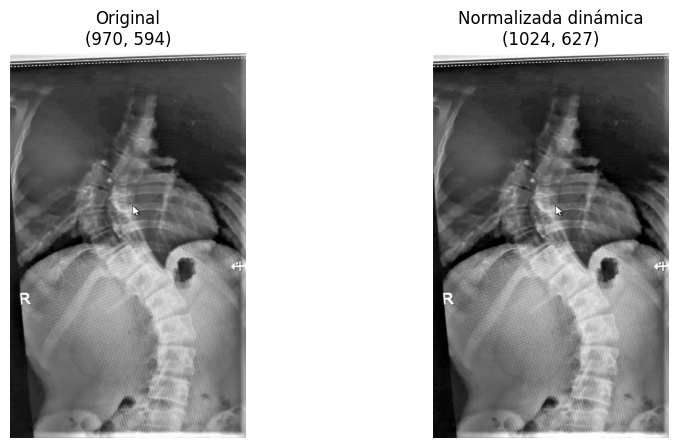

In [ ]:
# ============================================================
# BLOQUE 07 — VISUALIZAR NORMALIZACIÓN DINÁMICA
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_original, cmap="gray")
plt.title(f"Original\n{img_original.shape}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_norm, cmap="gray")
plt.title(f"Normalizada dinámica\n{img_norm.shape}")
plt.axis("off")

plt.show()